# Simulation-based Inference

## Solution for Exercises-2

In [1]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## 1. Sampling from exponential distribution

### (a). Using any programming language, sample from an exponential distribution (with rate parameter 𝜆 = 5) on the basis of continuous uniform samples (𝑝 ∼ Uniform(0, 1)) utilising quantile function.

In [2]:
def sample_exponential(rate=5):
    """
    The exponential distribution's quantile function is given by:
      Q(p) = - (1 / rate) * ln(1 - p)
    where p ~ Uniform(0, 1).
    """
    # Generate a uniform random number between 0 and 1
    p = random.uniform(0, 1)

    # Calculate the exponential sample using the quantile function
    x = - (1 / rate) * math.log(1 - p)
    return x



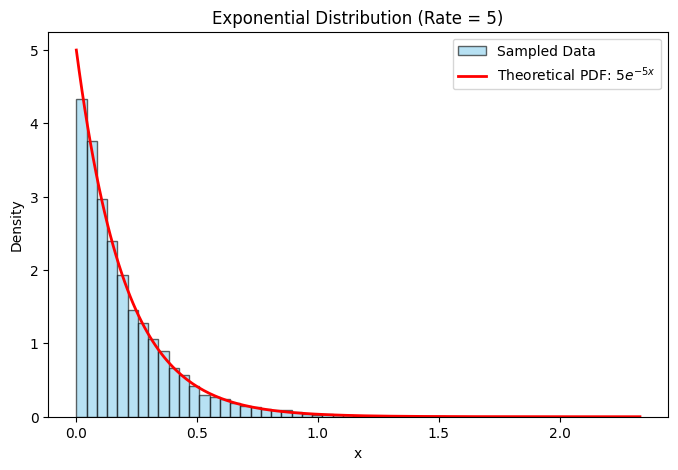

In [3]:
# Parameters
rate = 5
num_samples = 10000

# Generate samples
samples = [sample_exponential(rate) for _ in range(num_samples)]


fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = ax.hist(samples, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sampled Data')

x = np.linspace(0, max(samples)*1.1, 200)
pdf = rate * np.exp(-rate * x)  # f(x) = 5 * exp(-5*x)


ax.plot(x, pdf, 'r-', lw=2, label=f'Theoretical PDF: $5e^{{-5x}}$') # Overlay the theoretical exponential PDF

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Exponential Distribution (Rate = 5)')
ax.legend()
plt.show()

### (c). Sample from a Poisson distribution (with mean parameter 5) using samples from the exponential distribution.

In [4]:
def sample_poisson(mean=5):
    """
    Generate one sample from the Poisson distribution with mean 5 using
    samples from the exponential distribution.

    Algorithm:
      1. Initialize cumulative sum S = 0 and count = 0.
      2. While S ≤ 1:
           - Generate an exponential sample and add it to S.
           - Increment count by 1.
      3. Return count - 1 as the Poisson sample.
    """
    threshold = 1.0
    cumulative_sum = 0.0
    count = 0
    while cumulative_sum <= threshold:
        cumulative_sum += sample_exponential(rate=mean)
        count += 1
    return count - 1  # the last sample pushed S over the threshold

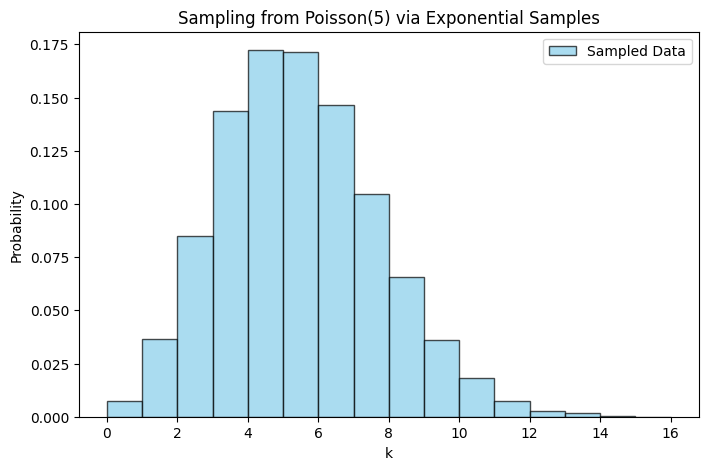

In [5]:
num_samples = 10000 # Generate multiple Poisson samples
poisson_samples = [sample_poisson(mean=5) for _ in range(num_samples)]

# Visualize the generated Poisson samples using a histogram.
plt.figure(figsize=(8, 5))
# Use integer bins from the minimum to maximum values of the samples.
bins = range(min(poisson_samples), max(poisson_samples) + 2)
plt.hist(poisson_samples, bins=bins, density=True, color='skyblue',
         edgecolor='black', alpha=0.7, label='Sampled Data')


plt.xlabel('k')
plt.ylabel('Probability')
plt.title('Sampling from Poisson(5) via Exponential Samples')
plt.legend()
plt.show()

## 2. Importance Sampling

### Estimate the tail probability of 𝜃 = 𝑃 (𝑋 > 2) where 𝑋 is Cauchy distributed.

In [8]:
# Define the quantile function for a standard Cauchy distribution.
# The CDF of a standard Cauchy is: F(x) = 1/2 + (1/π) arctan(x)
# Inverting this, the quantile function is: Q(p) = tan( π(p - 1/2) )

def cauchy_quantile(p):
    return np.tan(np.pi * (p - 0.5))

### (a) Use regular Monte Carlo sampling.

In [12]:
# Number of samples
S = 100000

# Generate S uniform random samples from U(0,1)
uniform_samples = np.random.uniform(0, 1, S)

# Generate Cauchy samples using the quantile function
cauchy_samples = cauchy_quantile(uniform_samples)

# Estimate the tail probability: P(X > 2)
# Here, f(x) = I{x > 2}, so we compute the mean of the indicator function.
tail_probability_estimate = np.mean(cauchy_samples > 2)

# Compute the true tail probability:
# CDF for standard Cauchy: F(x) = 1/2 + (1/π) arctan(x)
F_2 = 0.5 + (1.0/math.pi) * math.atan(2)
true_tail_probability = 1 - F_2

# Print the estimated and true values
print("Estimated tail probability P(X > 2):", tail_probability_estimate)
print("True tail probability P(X > 2):", true_tail_probability)

Estimated tail probability P(X > 2): 0.14571
True tail probability P(X > 2): 0.14758361765043326


### (b) Use importance sampling with a standard-normal distribution as the proposal distribution.

In [22]:
# Define the target density: Standard Cauchy
def p_cauchy(x):
    return 1.0 / (math.pi * (1 + x**2))

# Define the proposal density: Standard Normal
def q_normal(x):
    return (1.0 / np.sqrt(2 * math.pi)) * np.exp(-x**2 / 2)


S = 100000
proposal_samples = np.random.normal(loc=0, scale=1, size=S)

#importance weights: w(x) = p(x) / q(x)
weights = np.array([p_cauchy(x) / q_normal(x) for x in proposal_samples])

# For tail probability estimation, define f(x)= I{x > 2}
indicator = (proposal_samples > 2).astype(np.float64)

# Self-normalized importance sampling estimator for the tail probability:
# theta ≈ (sum_{i} I{x_i>2} * w(x_i)) / (sum_{i} w(x_i))
theta_estimated = np.sum(indicator * weights) / np.sum(weights)

# Computing the true tail probability using the Cauchy CDF:
F_2 = 0.5 + (1.0 / math.pi) * math.atan(2)
theta_true = 1 - F_2

print("Estimated tail probability P(X > 2):", theta_estimated)
print("True tail probability P(X > 2):", theta_true)

Estimated tail probability P(X > 2): 0.14572615239087375
True tail probability P(X > 2): 0.14758361765043326


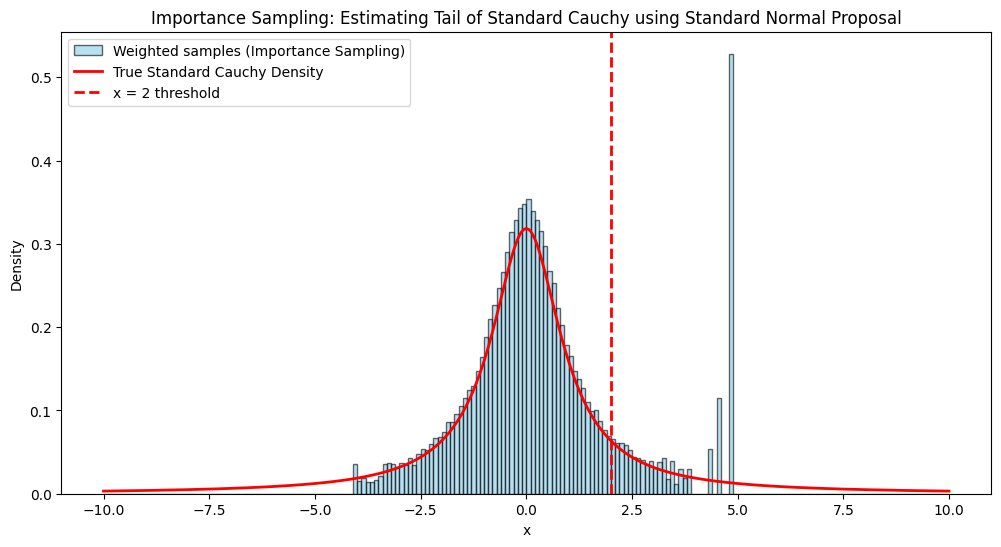

In [23]:
# Visualization

plt.figure(figsize=(12, 6))
normalized_weights = weights / np.sum(weights)

bins = 200

plt.hist(proposal_samples, bins=bins, range=(-10,10), weights=normalized_weights,
         density=True, alpha=0.6, color='skyblue', edgecolor='black',
         label='Weighted samples (Importance Sampling)')

x_grid = np.linspace(-10, 10, 500)
cauchy_density = np.array([p_cauchy(x) for x in x_grid])
plt.plot(x_grid, cauchy_density, 'r-', lw=2, label='True Standard Cauchy Density')

# Mark the threshold x = 2 with a vertical dashed red line.
plt.axvline(2, color='red', linestyle='--', lw=2, label='x = 2 threshold')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Importance Sampling: Estimating Tail of Standard Cauchy using Standard Normal Proposal')
plt.legend()
plt.show()

### (c) Use importance sampling with a truncated Cauchy distribution as the proposal distribution.

In [26]:
# -------------------------------
# Target: Standard Cauchy
# -------------------------------
def p_target(x):
    return 1.0 / (math.pi * (1 + x**2))

def F_target(x):
    return 0.5 + (1.0/math.pi) * math.atan(x)

true_tail_prob = 1 - F_target(2)

# -------------------------------
# Proposal: One‐sided truncated Cauchy on [2, b]
# -------------------------------
a = 2.0         # lower truncation at threshold
b = 1000.0       # approximate +∞
s = 0.5         # scale of proposal

# full‐CDF and density of Cauchy(0, s)
def F_full(x):
    return 0.5 + (1.0/math.pi) * math.atan(x/s)

def f_full(x):
    return 1.0/(math.pi * s * (1 + (x/s)**2))

# normalization constant for truncation [a,b]
Z = F_full(b) - F_full(a)

def q_prop(x):
    """Truncated‐Cauchy proposal density on [a,b]."""
    return (f_full(x) / Z) if (a <= x <= b) else 0.0

def Q_prop(u):
    """
    Inverse‐CDF sampling from truncated Cauchy:
      1) map u∈[0,1] → p∈[F(a),F(b)] via p = u*Z + F(a)
      2) invert full‐CDF: x = s*tan(pi*(p-0.5))
    """
    p = u * Z + F_full(a)
    return s * math.tan(math.pi * (p - 0.5))

# -------------------------------
# Importance Sampling
# -------------------------------
S = 100000
u = np.random.rand(S)
xs = np.array([Q_prop(ui) for ui in u])       # proposal samples in [2,b]
ws = np.array([p_target(x)/q_prop(x) for x in xs])  # importance weights

# estimate P(X>2) = E_q[ I{x>2} * w(x) ] / E_q[w(x)]
# but here all xs>2 by construction, so indicator=1
theta_hat = ws.mean()  #we need unnormalized formula:


print("Estimated P(X>2) via one‐sided truncated Cauchy proposal:", theta_hat)
print("True P(X>2):", true_tail_prob)


Estimated P(X>2) via one‐sided truncated Cauchy proposal: 0.14727154692462463
True P(X>2): 0.14758361765043326


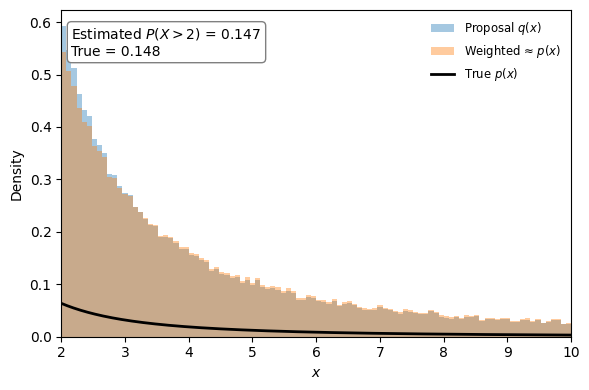

In [27]:
fig, ax = plt.subplots(1,1, figsize=(6,4))


ax.hist(xs, bins=100, range=(2,10), density=True,
        alpha=0.4, label='Proposal $q(x)$')

ax.hist(xs, bins=100, range=(2,10),
        weights=ws, density=True,
        alpha=0.4, label='Weighted ≈ $p(x)$')

x_grid = np.linspace(2,10,500)
ax.plot(x_grid, [p_target(x) for x in x_grid],
        'k-', lw=2, label='True $p(x)$')

ax.set_xlim(2,10)
ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.legend(fontsize='small', ncol=1, loc='upper right', frameon=False)


ax.text(0.02, 0.95,
        f'Estimated $P(X>2)$ = {theta_hat:.3f}\nTrue = {true_tail_prob:.3f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()